In [57]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import norm
import seaborn as sns
import sqlite3
import os
from tqdm import tqdm
sns.set_theme(style="darkgrid", palette="Set2")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "text.usetex": True
})

os.environ["PATH"] = os.path.expanduser("~/texlive2025/bin/x86_64-linux") + os.pathsep + os.environ.get("PATH", "")



In [58]:
def combine_results_all(max_num_jobs, types, db_path="results.sqlite", results_dir="results", chunksize=100000, with_noise=False, noise_level=0):
    if os.path.exists(db_path): #remove previous db
        os.remove(db_path)
    for type in tqdm(types):
        for with_clone in ["_with_clone", "_without_clone"]:
            for postfix in ["", "_yrwr"]:
                combine_results(max_num_jobs, f"{type}{postfix}{with_clone}", db_path, results_dir, if_exists="append", chunksize=chunksize, with_noise=with_noise, noise_level=noise_level)

        postfixes = ["_kt_distance_with_clone", "_kt_distance_yrwr_with_clone", "_order_violations", "_kt_distance_bw_mechanisms"]
        for postfix in postfixes:
            combine_results(max_num_jobs, f"{type}{postfix}", db_path, results_dir, if_exists="append", chunksize=chunksize, with_noise=with_noise, noise_level=noise_level)


def combine_results(max_num_jobs, table, db_path="results.sqlite", results_dir="results", if_exists="replace", chunksize=100000, with_noise=False, noise_level=0):
    with sqlite3.connect(db_path) as out_conn:
        wrote_any = False

        for i in range(max_num_jobs):
            in_path = f"{results_dir}/job_{i}{f'_noisy_{noise_level}' if with_noise else ''}.sqlite"
            if not os.path.exists(in_path):
                continue
            with sqlite3.connect(in_path) as in_conn:
                try:
                    for chunk in pd.read_sql(f"SELECT * FROM {table}", in_conn, chunksize=chunksize):
                        mode = if_exists if not wrote_any else "append"
                        chunk.to_sql(table, out_conn, if_exists=mode, index=False)
                        wrote_any = True
                except pd.errors.DatabaseError:
                    print(f"Error reading {table} for job {i}")

def plot_modalities(df, ax, title):
    sns.lineplot(data=df, ax=ax, palette="plasma", dashes=False, marker="o")
    ax.set_title(title)
    ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_xticks(range(1, 6))

def plot_rank_differences(df_with_clone, df_without_clone, ax, title):
    diff = df_without_clone.mean() - df_with_clone.groupby("num_clones").mean()
    plot_modalities(diff, ax, title)

def plot_ranks(df):
    fig, ax = plt.subplots(figsize=(10, 6))
    model_names = list(df.index)
    sns.boxplot(data=df, ax=ax)
    ax.set_xlabel("Model")
    ax.set_ylabel("Rank")
    ax.set_xticklabels(model_names, rotation=90)
    plt.show()

def load_all(table, db_path="results.sqlite"):
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql(f"SELECT * FROM {table}", conn)

def get_model_org_dicts(typ):
    df = pd.read_csv(f"parsed_tables/{typ}.csv", index_col="Model")

    alpha = 400 / math.log(10)
    true_abilities = (df['Score'] - 1000) / alpha # convert to unscaled abilities
    M = len(true_abilities)
    model_names = list(true_abilities.index)

    org_to_models = (
        df.reset_index()
            .sort_values('Score', ascending=False)
            .groupby('Organization')['Model']
            .apply(lambda models: [model_names.index(m) for m in models])
            .to_dict()
    )
    model_to_org = df.reset_index().set_index("Model")["Organization"].to_dict()
    return model_to_org, org_to_models, model_names
    
def kt_corr_to_kt_distance(kt_corr, M):
    return (1 - kt_corr) * M * (M-1) / 4


In [59]:
# TYPES = ["coding", "ahp", "image-edit", "text", "text-to-image", "text-to-video", "vision", "webdev"]
top_level_types = ["vision","coding", "webdev", "texttoimage", "imageedit", "imagetovideo"]
occuptationals = ["text_occupational_" + t for t in ["business", "entertainment", "legal", "life_physical_social_science", "mathematical", "software_it_services", "writing_literature", "medicine"]]
# text_categories = ["text_" + t for t in ["coding", "expert", "hard_prompts", "instruction_following", "longer_query", "multiturn"]]
text_categories = ["text_" + t for t in ["coding", "expert", "hard_prompts", "longer_query", "multiturn"]]
# vision_categories = ["vision_" + t for t in ["captioning", "diagram", "ocr"]]
TYPES = ["text"] + text_categories #+ top_level_types 

TYPES = ["imageedit", "imagetovideo"]

TYPES_WITHOUT_DASHES = [t.replace("-", "") for t in TYPES]
n_jobs = 100

noise_levels = [10**-i for i in range(2,7)]
noise_levels_text = noise_levels


In [60]:
for noise_level in noise_levels_text:
    combine_results_all(n_jobs, TYPES_WITHOUT_DASHES, db_path=f"results_noisy_{noise_level}.sqlite", results_dir="results", with_noise=True, chunksize=500000, noise_level=noise_level)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:43<00:00, 21.72s/it]


In [134]:
combine_results_all(n_jobs, TYPES_WITHOUT_DASHES, results_dir="results")

with sqlite3.connect("results.sqlite") as conn:
    cursor = conn.cursor()
    tables = cursor.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
    print("Tables in the database:", [t[0] for t in tables])

 58%|█████▊    | 7/12 [17:34<10:16, 123.34s/it]

Error reading coding_with_clone for job 0
Error reading coding_with_clone for job 1
Error reading coding_with_clone for job 2
Error reading coding_with_clone for job 3
Error reading coding_with_clone for job 4
Error reading coding_with_clone for job 5
Error reading coding_with_clone for job 6
Error reading coding_with_clone for job 7
Error reading coding_with_clone for job 8
Error reading coding_with_clone for job 9
Error reading coding_with_clone for job 10
Error reading coding_with_clone for job 11
Error reading coding_with_clone for job 12
Error reading coding_with_clone for job 13
Error reading coding_with_clone for job 14
Error reading coding_with_clone for job 15
Error reading coding_with_clone for job 16
Error reading coding_with_clone for job 17
Error reading coding_with_clone for job 18
Error reading coding_with_clone for job 19
Error reading coding_with_clone for job 20
Error reading coding_with_clone for job 21
Error reading coding_with_clone for job 22
Error reading coding_

 67%|██████▋   | 8/12 [18:02<06:12, 93.05s/it] 

Error reading coding_kt_distance_bw_mechanisms for job 93
Error reading coding_kt_distance_bw_mechanisms for job 94
Error reading coding_kt_distance_bw_mechanisms for job 95
Error reading coding_kt_distance_bw_mechanisms for job 96
Error reading coding_kt_distance_bw_mechanisms for job 97
Error reading coding_kt_distance_bw_mechanisms for job 98
Error reading coding_kt_distance_bw_mechanisms for job 99


100%|██████████| 12/12 [19:22<00:00, 96.90s/it]

Tables in the database: ['text_with_clone', 'text_yrwr_with_clone', 'text_without_clone', 'text_yrwr_without_clone', 'text_kt_distance_with_clone', 'text_kt_distance_yrwr_with_clone', 'text_order_violations', 'text_kt_distance_bw_mechanisms', 'text_coding_with_clone', 'text_coding_yrwr_with_clone', 'text_coding_without_clone', 'text_coding_yrwr_without_clone', 'text_coding_kt_distance_with_clone', 'text_coding_kt_distance_yrwr_with_clone', 'text_coding_order_violations', 'text_coding_kt_distance_bw_mechanisms', 'text_expert_with_clone', 'text_expert_yrwr_with_clone', 'text_expert_without_clone', 'text_expert_yrwr_without_clone', 'text_expert_kt_distance_with_clone', 'text_expert_kt_distance_yrwr_with_clone', 'text_expert_order_violations', 'text_expert_kt_distance_bw_mechanisms', 'text_hard_prompts_with_clone', 'text_hard_prompts_yrwr_with_clone', 'text_hard_prompts_without_clone', 'text_hard_prompts_yrwr_without_clone', 'text_hard_prompts_kt_distance_with_clone', 'text_hard_prompts_kt

In [61]:
TYPE_NAMES = {
    "text": "Text",
    "vision": "Vision",
    "text_coding": "Coding",
    "webdev": "Web Development",
    "texttoimage": "Text to Image",
    "imageedit": "Image Edit",
    "search": "Search",
    "imagetovideo": "Image to Video",
    "text_creative_writing": "Creative Writing",
    "text_expert": "Expert",
    "text_hard_prompts": "Hard Prompts",
    "text_instruction_following": "Instruction Following",
    "text_longer_query": "Longer Query",
    "text_multiturn": "Multiturn",
    "text_occupational_business": "Occupational: Business",
    "text_occupational_entertainment": "Occupational: Entertainment",
    "text_occupational_legal": "Occupational: Legal",
    "text_occupational_life_physical_social_science": "Occupational: Life, Physical, Social Science",
    "text_occupational_mathematical": "Occupational: Mathematical",
    "text_occupational_software_it_services": "Occupational: Software, IT Services",
    "text_occupational_writing_literature": "Occupational: Writing, Literature",
    "text_occupational_medicine": "Occupational: Medicine",
    "vision_captioning": "Captioning",
    "vision_diagram": "Diagram",
    "vision_ocr": "OCR",
}

In [14]:
df_with_clone = {}
df_without_clone = {}
df_yrwr_with_clone = {}
df_yrwr_without_clone = {}
df_kt_distance_with_clone = {}
df_kt_distance_yrwr_with_clone = {}
df_order_violations = {}
df_kt_dist_bw_mechanisms = {}
for type in TYPES_WITHOUT_DASHES:
    df_with_clone[type] = load_all(f"{type}_with_clone")
    df_without_clone[type] = load_all(f"{type}_without_clone")
    df_yrwr_with_clone[type] = load_all(f"{type}_yrwr_with_clone")
    df_yrwr_without_clone[type] = load_all(f"{type}_yrwr_without_clone")
    df_kt_distance_with_clone[type] = load_all(f"{type}_kt_distance_with_clone")
    df_kt_distance_yrwr_with_clone[type] = load_all(f"{type}_kt_distance_yrwr_with_clone")
    # df_order_violations[type] = load_all(f"{type}_order_violations")
    df_kt_dist_bw_mechanisms[type] = load_all(f"{type}_kt_distance_bw_mechanisms")

In [62]:
df_kt_distance_with_clone_noisy = [{} for _ in noise_levels]
df_kt_distance_yrwr_with_clone_noisy = [{} for _ in noise_levels]

for i,noise_level in enumerate(noise_levels_text):
    for type in TYPES_WITHOUT_DASHES:
        df_kt_distance_with_clone_noisy[i][type] = load_all(f"{type}_kt_distance_with_clone", f"results_noisy_{noise_level}.sqlite")
        df_kt_distance_yrwr_with_clone_noisy[i][type] = load_all(f"{type}_kt_distance_yrwr_with_clone", f"results_noisy_{noise_level}.sqlite")


In [7]:
mean_num_votes = {}
for typ in TYPES_WITHOUT_DASHES:
    parsed_df = pd.read_csv(f"parsed_tables/{typ}.csv")
    n_models = len(parsed_df)
    mean_num_votes[typ] = 2 * parsed_df['Votes'].sum() / (n_models * (n_models - 1))

mean_num_votes_df = pd.DataFrame(mean_num_votes.items(), columns=['Type', 'Mean Number of Votes'])
mean_num_votes_df


,Type,Mean Number of Votes
0,text,173.278625
1,text_coding,30.439518
2,text_expert,12.151117
3,text_hard_prompts,58.513161
4,text_longer_query,29.097922
5,text_multiturn,28.442640


In [8]:
num_models = {}
for typ in TYPES_WITHOUT_DASHES:
    num_models[typ] = len(df_with_clone[typ].columns)
num_models_df = pd.DataFrame(num_models.items(), columns=['Type', 'Number of Models'])
num_models_df


,Type,Number of Models
0,text,294
1,text_coding,290
2,text_expert,245
3,text_hard_prompts,294
4,text_longer_query,273
5,text_multiturn,293


In [7]:
rows = []
for typ in TYPES_WITHOUT_DASHES:
    n_models = len(df_with_clone[typ].columns)
    total_num_simulations = 3 * 5 * 48 * n_models
    num_violations = len(df_order_violations[typ])
    p_violation = num_violations / total_num_simulations
    se_p_violation = np.sqrt(p_violation * (1 - p_violation) / total_num_simulations)
    rows.append({
        "Type": TYPE_NAMES[typ],
        "Percent Violations": f"{100*p_violation:.2f} ({100*se_p_violation:.2f})"
    })

violations_df = pd.DataFrame(rows)
# print(violations_df.to_latex(index=False, escape=False))
violations_df

KeyError: 'text'

In [33]:
B = 3
max_num_clones = 5
n_jobs = 100
sims_per_pair = B * max_num_clones * n_jobs

n_modalities = len(df_with_clone.values())

fig, axes = plt.subplots(n_modalities // 4, 4, figsize=(16, 8))
# fig, axes = plt.subplots(2, 2, figsize=(6, 3.5))

for i, typ in enumerate(TYPES_WITHOUT_DASHES):
    grouped = df_order_violations[typ].groupby(['model_ahead', 'model_to_clone']).size().reset_index(name='count')
    grouped['percent_violations'] = 100 * grouped['count'] / sims_per_pair

    bins = np.arange(0, 110, 5)
    axes[i // 4, i % 4].hist(grouped['percent_violations'], bins=bins, edgecolor='black')
    axes[i // 4, i % 4].set_title(f'{TYPE_NAMES[typ]}')
    axes[i // 4, i % 4].set_xlim(0, 110)

fig.supxlabel('Percent Violations')
fig.supylabel('Frequency')
plt.tight_layout()
plt.show()

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1600x800 with 0 Axes>

In [ ]:
typ = 'text'
model_to_org, org_to_models, model_names = get_model_org_dicts(typ)
grouped = df_order_violations[typ].groupby(['model_ahead', 'model_to_clone']).size().reset_index(name='count')
grouped['percent_violations'] = 100 * grouped['count'] / sims_per_pair
high_violations = grouped[grouped['percent_violations'] > 40]
high_violations_named = high_violations.copy()
high_violations_named['organization'] = high_violations_named['model_to_clone'].apply(lambda idx: model_to_org[model_names[idx]])
high_violations_named['model_to_clone'] = high_violations_named['model_to_clone'].apply(lambda idx: model_names[idx])
high_violations_named = high_violations_named.rename(columns={'model_to_clone': 'model_behind'})
high_violations_named['model_ahead'] = high_violations_named['model_ahead'].apply(lambda idx: model_names[idx])

print(high_violations_named[['model_ahead', 'model_behind', 'percent_violations']].to_string(index=False))

                                      model_ahead                                      model_behind  percent_violations
                                     gemini-3-pro                                    gemini-3-flash         2939.933333
                                   gemini-3-flash                 gemini-3-flash (thinking-minimal)         2939.933333
                                grok-4.1-thinking                                          grok-4.1         2940.000000
   Anthropicclaude-opus-4-5-20251101-thinking-32k                 Anthropicclaude-opus-4-5-20251101         2606.466667
   Anthropicclaude-opus-4-5-20251101-thinking-32k  Anthropicclaude-sonnet-4-5-20250929-thinking-32k          340.000000
                Anthropicclaude-opus-4-5-20251101  Anthropicclaude-sonnet-4-5-20250929-thinking-32k         2610.000000
                                         grok-4.1                           grok-4-1-fast-reasoning         2940.000000
                gemini-3-flash (thinking

In [10]:
typ = 'vision'
model_to_org, org_to_models, model_names = get_model_org_dicts(typ)
grouped = df_order_violations[typ].groupby(['model_ahead', 'model_to_clone']).size().reset_index(name='count')
grouped['percent_violations'] = 100 * grouped['count'] / sims_per_pair
high_violations = grouped[grouped['percent_violations'] > 40]
high_violations_named = high_violations.copy()
high_violations_named['organization'] = high_violations_named['model_to_clone'].apply(lambda idx: model_to_org[model_names[idx]])
high_violations_named['model_to_clone'] = high_violations_named['model_to_clone'].apply(lambda idx: model_names[idx])
high_violations_named['model_ahead'] = high_violations_named['model_ahead'].apply(lambda idx: model_names[idx])

print(high_violations_named[['model_ahead', 'model_to_clone', 'percent_violations']].to_string(index=False))

                                      model_ahead                    model_to_clone  percent_violations
                                          gpt-5.1        chatgpt-4o-latest-20250326           41.944444
                       gpt-4.5-preview-2025-02-27                        gpt-5-chat           40.694444
                                    o3-2025-04-16                gpt-4.1-2025-04-14           60.000000
                          gpt-4.1-mini-2025-04-14                o4-mini-2025-04-16          100.555556
                  Anthropicclaude-opus-4-20250514 Anthropicclaude-sonnet-4-20250514           59.305556
gemini-2.5-flash-lite-preview-09-2025-no-thinking                gemini-1.5-pro-002          105.972222
                                     qwen2-vl-72b                  qwen-vl-max-1119          105.138889
                            amazon-nova-lite-v1.0              amazon-nova-pro-v1.0          102.500000


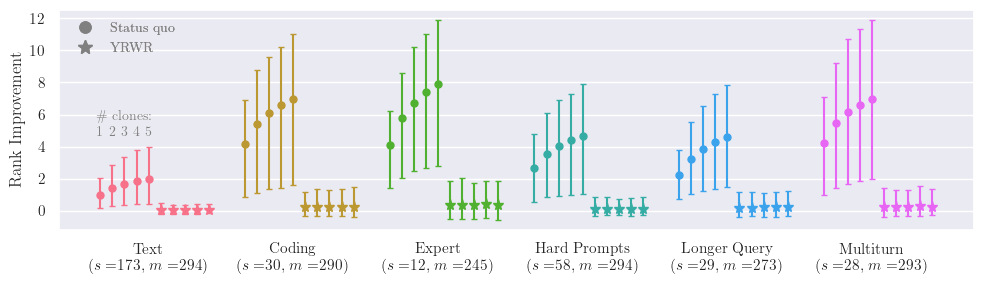

In [16]:
fig, ax = plt.subplots(figsize=(10, 3))

means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
mins = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
maxs = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
means_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
mins_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
maxs_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
for type in TYPES_WITHOUT_DASHES:
    diff = (df_without_clone[type].mean() - df_with_clone[type].groupby("num_clones").mean())
    means[type] = diff.mean(axis=1)
    mins[type] = diff.quantile(0.05, axis=1)
    maxs[type] = diff.quantile(0.95, axis=1)
    diff_yrwr = (df_yrwr_without_clone[type].mean() - df_yrwr_with_clone[type].groupby("num_clones").mean())
    means_yrwr[type] = diff_yrwr.mean(axis=1)
    mins_yrwr[type] = diff_yrwr.quantile(0.05, axis=1)
    maxs_yrwr[type] = diff_yrwr.quantile(0.95, axis=1)

palette=sns.color_palette("husl", len(TYPES_WITHOUT_DASHES))
type_offset = 12
offset = 5

for i, col in enumerate(means.columns):
    ax.errorbar(
        range(type_offset*i + 1, type_offset*i + 6),
        means[col],
        yerr=[means[col] - mins[col], maxs[col] - means[col]],
        marker="o",
        linestyle = 'none',  # Ensures no gap between points
        capsize = 2,  # Add caps to each error bar
        color=palette[i],
        label=col,
        markersize=5
    )
    ax.errorbar(
        range(type_offset*i + 1 + offset, type_offset*i + 6 + offset),
        means_yrwr[col],
        yerr=[means_yrwr[col] - mins_yrwr[col], maxs_yrwr[col] - means_yrwr[col]],
        marker="*",
        linestyle = 'none',  # Ensures no gap between points
        capsize = 2,  # Add caps to each error bar
        color=palette[i],
        label=col,
        markersize=8
    )

ax.grid(axis='x', visible=False)
ax.grid(axis='y', visible=True)

xtick_positions = [i * type_offset + offset for i in range(len(means.columns))]
xtick_labels = [f"{TYPE_NAMES[col]}\n($s=${int(mean_num_votes[col])}, $m=${num_models[col]:.0f})" for col in means.columns]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=0)

status_quo_marker = mlines.Line2D([], [], color="gray", marker="o", linestyle='None',
                                  markersize=8, label="Status quo")
yrwr_marker = mlines.Line2D([], [], color="gray", marker="*", linestyle='None',
                            markersize=10, label="YRWR")
legend1 = ax.legend(handles=[status_quo_marker, yrwr_marker], loc='upper left', frameon=False, fontsize=10)
for text in legend1.get_texts():
    text.set_color("gray")

max_locs = [maxs["text"].iloc[i] for i in range(len(maxs["text"]))]
ax.text(3, max(max_locs) + 2.25, "\# clones:", ha='center', va='top', fontsize=10, color="gray")
for i in range(len(max_locs)):
    ax.text(i+1, max(max_locs) + 0.5,  str(i+1), ha='center', va='bottom', fontsize=10, color="gray")

# Optionally, add back the type legend as a second legend (if desired)
ax.add_artist(legend1)

ax.set_ylabel("Rank Improvement")
fig.tight_layout()
plt.savefig("plots/rank_difference.png", dpi=500)

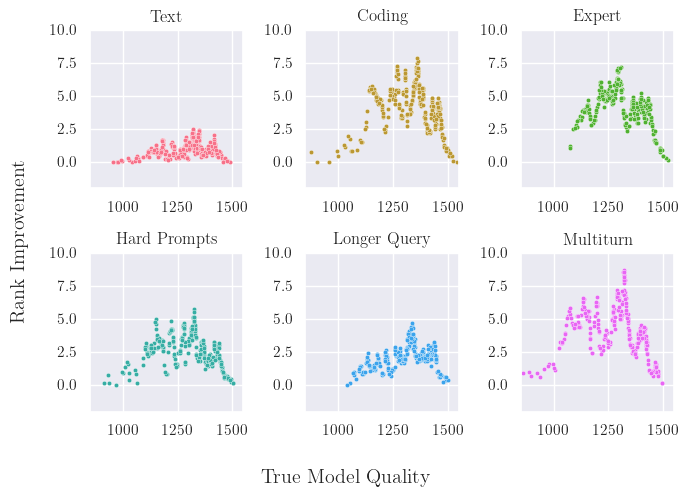

In [24]:
n_modalities = len(TYPES_WITHOUT_DASHES)
fig, axes = plt.subplots(nrows=n_modalities // 3, ncols=3, figsize=(3.7 * n_modalities // 3, 5 ))


max_rank = 300
num_clones = 1

means = {}
sds = {}
means_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
merged = {}
for type in TYPES_WITHOUT_DASHES:
    parsed_df = pd.read_csv(f"parsed_tables/{type}.csv")
    means[type] = pd.Series((df_without_clone[type].mean() - df_with_clone[type][df_with_clone[type]["num_clones"] == num_clones].mean())[:max_rank])
    sds[type] = pd.Series(((df_without_clone[type] - df_with_clone[type][df_with_clone[type]["num_clones"] == num_clones]).std())[:max_rank])
    means_df = pd.DataFrame({"mean": means[type], "sd": sds[type]})
    merged[type] = pd.merge(
        means_df,
        parsed_df[["Model", "Score"]],
        left_index=True,
        right_on="Model",
        how="inner"
    )[[ "mean", "sd", "Score" ]]

palette = sns.color_palette("husl", len(TYPES_WITHOUT_DASHES))

for i, type in enumerate(TYPES_WITHOUT_DASHES):
    # Add 95% confidence intervals as error bars to each point

    num_simulations = len(df_without_clone[type])
    # If not, set n to the number of samples used per mean estimation
    ci_lo = merged[type]["mean"] - norm.ppf(0.975) * merged[type]["sd"] / np.sqrt(num_simulations)
    ci_hi = merged[type]["mean"] + norm.ppf(0.975) * merged[type]["sd"] / np.sqrt(num_simulations)

    # Plot errorbars before scatter for visibility
    # axes[i//4, i%4].errorbar(
    #     merged[type]["Score"],
    #     merged[type]["mean"],
    #     yerr=[merged[type]["mean"] - ci_lo, ci_hi - merged[type]["mean"]],
    #     fmt='none',
    #     ecolor=palette[i],
    #     elinewidth=0.6,
    #     capsize=1.5,
    #     alpha=0.7,
    #     zorder=1
    # )
    sns.scatterplot(x=merged[type]["Score"], y=merged[type]["mean"], ax=axes[i//3, i%3], color=palette[i], s=10)
    axes[i//3, i%3].set_title(TYPE_NAMES[type])
    axes[i//3, i%3].set_xlabel('')
    axes[i//3, i%3].set_ylabel('')
    axes[i//3, i%3].set_xlim(850, 1550)
    axes[i//3, i%3].set_ylim(-2, 10)

fig.supxlabel("True Model Quality")
fig.supylabel("Rank Improvement")
# fig.suptitle(f"Number of clones = {num_clones}")

plt.tight_layout()
plt.savefig(f"plots/rank_difference_by_quality_{num_clones}.png", dpi=500)

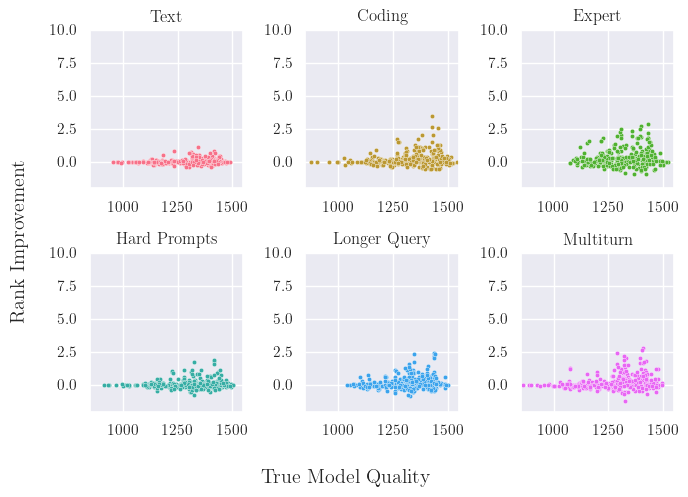

In [25]:
n_modalities = len(TYPES_WITHOUT_DASHES)
fig, axes = plt.subplots(nrows=n_modalities // 3, ncols=3, figsize=(3.7 * n_modalities // 3, 5 ))


max_rank = 300
num_clones = 1

means = {}
sds = {}
means_yrwr = {} 
merged = {}
for type in TYPES_WITHOUT_DASHES:
    parsed_df = pd.read_csv(f"parsed_tables/{type}.csv")
    means[type] = pd.Series((df_yrwr_without_clone[type].mean() - df_yrwr_with_clone[type][df_yrwr_with_clone[type]["num_clones"] == num_clones].mean())[:max_rank])
    sds[type] = pd.Series(((df_yrwr_without_clone[type] - df_yrwr_with_clone[type][df_yrwr_with_clone[type]["num_clones"] == num_clones]).std())[:max_rank])
    means_df = pd.DataFrame({"mean": means[type], "sd": sds[type]})
    merged[type] = pd.merge(
        means_df,
        parsed_df[["Model", "Score"]],
        left_index=True,
        right_on="Model",
        how="inner"
    )[[ "mean", "sd", "Score" ]]

palette = sns.color_palette("husl", len(TYPES_WITHOUT_DASHES))

for i, type in enumerate(TYPES_WITHOUT_DASHES):
    # Add 95% confidence intervals as error bars to each point
    num_simulations = len(df_yrwr_without_clone[type])
    ci_lo = merged[type]["mean"] - norm.ppf(0.975) * merged[type]["sd"] / np.sqrt(num_simulations)
    ci_hi = merged[type]["mean"] + norm.ppf(0.975) * merged[type]["sd"] / np.sqrt(num_simulations)

    # Plot errorbars before scatter for visibility
    # axes[i//4, i%4].errorbar(
    #     merged[type]["Score"],
    #     merged[type]["mean"],
    #     yerr=[merged[type]["mean"] - ci_lo, ci_hi - merged[type]["mean"]],
    #     fmt='none',
    #     ecolor=palette[i],
    #     elinewidth=0.6,
    #     capsize=1.5,
    #     alpha=0.7,
    #     zorder=1
    # )
    sns.scatterplot(x=merged[type]["Score"], y=merged[type]["mean"], ax=axes[i//3, i%3], color=palette[i], s=10)
    axes[i//3, i%3].set_title(TYPE_NAMES[type])
    axes[i//3, i%3].set_xlabel('')
    axes[i//3, i%3].set_ylabel('')
    axes[i//3, i%3].set_xlim(850, 1550)
    axes[i//3, i%3].set_ylim(-2, 10)

fig.supxlabel("True Model Quality")
fig.supylabel("Rank Improvement")
# fig.suptitle(f"Number of clones = {num_clones}")

plt.tight_layout()
plt.savefig(f"plots/rank_difference_by_quality_{num_clones}_yrwr.png", dpi=500)

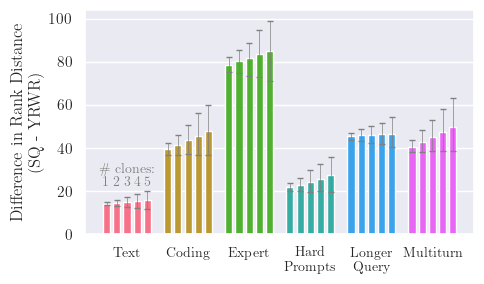

In [27]:
fig, ax = plt.subplots(figsize=(5, 3))

M = len(df_kt_distance_yrwr_with_clone[type].columns)
means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
mins = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
maxs = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
means_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
mins_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
maxs_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
for type in TYPES_WITHOUT_DASHES:
    diff_sq = kt_corr_to_kt_distance(df_kt_distance_with_clone[type].groupby("num_clones").mean(), M)
    diff_yrwr = kt_corr_to_kt_distance(df_kt_distance_yrwr_with_clone[type].groupby("num_clones").mean(), M)
    diff = diff_sq - diff_yrwr
    means[type] = diff.mean(axis=1)
    mins[type] = diff.quantile(0.05, axis=1)
    maxs[type] = diff.quantile(0.95, axis=1)

palette=sns.color_palette("husl", len(TYPES_WITHOUT_DASHES))
type_offset = 6
offset = 5

for i, col in enumerate(means.columns):
    ax.errorbar(
        range(type_offset*i + 1, type_offset*i + 6),
        means[col],
        yerr=[means[col] - mins[col], maxs[col] - means[col]],
        # marker="o",
        linestyle = 'none',  # Ensures no gap between points
        capsize = 2,  # Add caps to each error bar
        color="gray",
        label=col,
        markersize=5,
        linewidth=0.5
    )
    ax.bar(
        [type_offset*i + j + 1 for j in range(5)],  # bar positions for each clone number (1-5 per type)
        means[col].values,
        width=0.7,
        color=palette[i],
        # alpha=0.20,
        zorder=1
    )

ax.grid(axis='x', visible=False)
ax.grid(axis='y', visible=True)

xtick_positions = [i * type_offset + 3 for i in range(len(means.columns))]
# xtick_labels = [f"{TYPE_NAMES[col]}\n($s=${int(mean_num_votes[col])}, $m=${num_models[col]:.0f})" for col in means.columns]
xtick_labels = [f"{TYPE_NAMES[col]}" for col in means.columns]
xtick_labels = [label.replace(' ', '\n') for label in xtick_labels]

ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=0)
for label in ax.get_xticklabels():
    label.set_fontsize(10)

max_locs = [maxs["text"].iloc[i] for i in range(len(maxs["text"]))]
ax.text(3, max(max_locs) + 7, "\# clones:", ha='center', va='bottom', fontsize=10, color="gray")
for i in range(len(max_locs)):
    ax.text(i+1, max(max_locs) + 1,  str(i+1), ha='center', va='bottom', fontsize=10, color="gray")


ax.set_ylabel("Difference in Rank Distance \n (SQ - YRWR)")
fig.tight_layout()
plt.savefig("plots/bubble_sort_distance_difference.png", dpi=500)

imageedit
imagetovideo


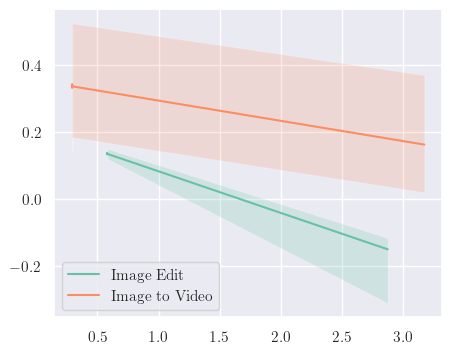

In [63]:

means = [pd.DataFrame(columns=TYPES_WITHOUT_DASHES) for _ in range(len(noise_levels_text))]
mins = [pd.DataFrame(columns=TYPES_WITHOUT_DASHES) for _ in range(len(noise_levels_text))]
maxs = [pd.DataFrame(columns=TYPES_WITHOUT_DASHES) for _ in range(len(noise_levels_text))]

mean_kt = [{} for _ in range(len(noise_levels_text))]
mean_kt_yrwr = [{} for _ in range(len(noise_levels_text))]

for k, noise_level in enumerate(noise_levels_text):
    for type in TYPES_WITHOUT_DASHES:
        M = len(df_kt_distance_yrwr_with_clone_noisy[k][type].columns)
        diff_sq = kt_corr_to_kt_distance(df_kt_distance_with_clone_noisy[k][type].groupby("num_clones").mean(), M)
        diff_yrwr = kt_corr_to_kt_distance(df_kt_distance_yrwr_with_clone_noisy[k][type].groupby("num_clones").mean(), M)
        mean_kt[k][type] = kt_corr_to_kt_distance(df_kt_distance_yrwr_with_clone_noisy[k][type]['kt_noise'].mean(), M)
        diff = (diff_sq - diff_yrwr).drop(columns=['kt_noise'])
        means[k][type] = diff.mean(axis=1)
        mins[k][type] = diff.quantile(0.05, axis=1)
        maxs[k][type] = diff.quantile(0.95, axis=1)

fig, ax = plt.subplots(figsize=(5, 4))
palette=sns.color_palette("husl", len(TYPES_WITHOUT_DASHES)) 
type_offset = 6
offset = 5
max_num_clones = 1

for i, col in enumerate(means[0].columns):
    print(col)
    kts = [mean_kt[k][col] for k in range(len(noise_levels_text))]
    ln = [means[k][col] for k in range(len(noise_levels_text))]
    ax.plot(kts, ln, label=TYPE_NAMES[col])
    upper = [maxs[k][col].values[0] for k in range(len(noise_levels_text))]
    lower = [mins[k][col].values[0] for k in range(len(noise_levels_text))]
    ax.fill_between(kts, upper, lower, alpha=0.2)

ax.legend()

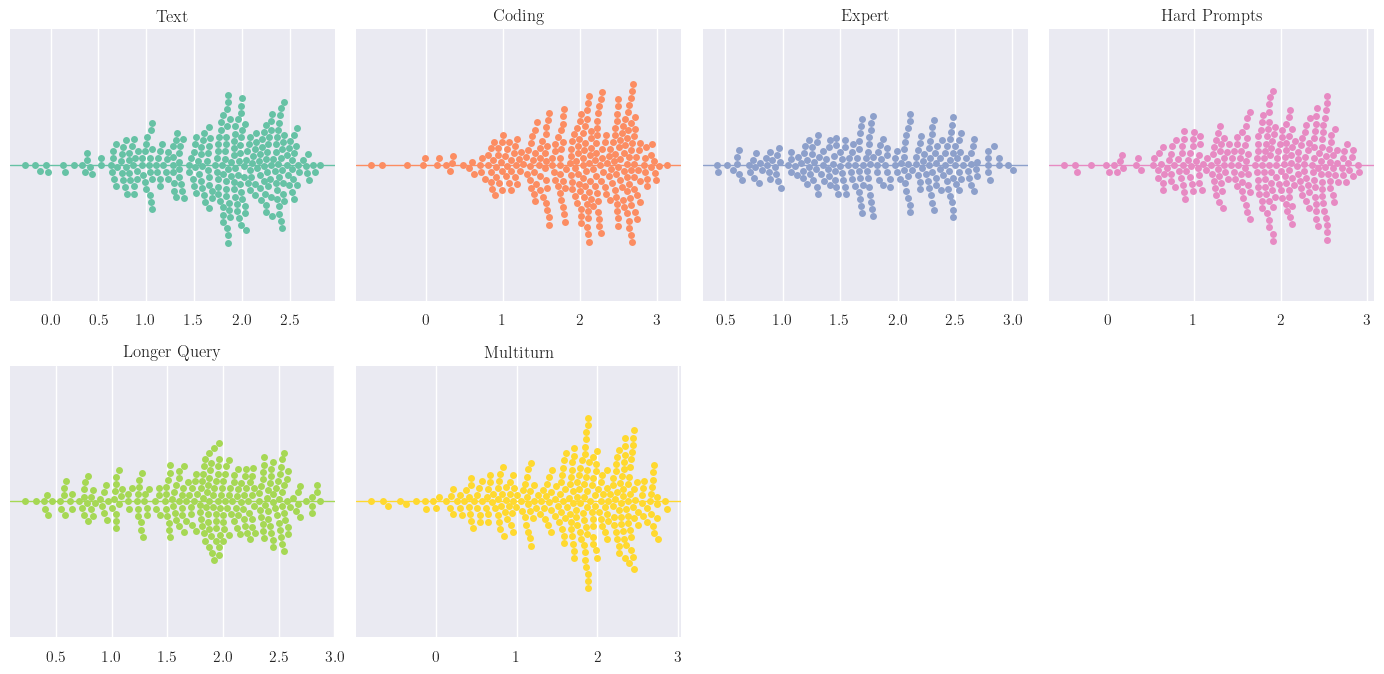

In [237]:
scores_dfs = {}
alpha = 400 / math.log(10)
for type in TYPES_WITHOUT_DASHES:
    df = pd.read_csv(f"parsed_tables/{type}.csv")
    scores_dfs[type] = df
    scores_dfs[type]["Score"] = (scores_dfs[type]["Score"] - 1000) / alpha

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(14, 10))
for i, type in enumerate(TYPES_WITHOUT_DASHES):
    sns.swarmplot(
        data=scores_dfs[type],
        x="Score",
        alpha=1,
        size=5,
        ax=axes[i//4, i%4],
        color=f"C{i}"
    )
    axes[i//4, i%4].axhline(y=0, lw=1, color=f"C{i}")
    axes[i//4, i%4].set_title(TYPE_NAMES[type])
    axes[i//4, i%4].set(yticks=[], ylabel="")
    # axes[i//4, i%4].set_xlim(900, 1600)
    axes[i//4, i%4].set_yticks([])
    axes[i//4, i%4].set_xlabel("")
    axes[i//4, i%4].set_ylabel("")
for ax_row in axes:
    for ax in (ax_row if isinstance(ax_row, (list, np.ndarray)) else [ax_row]):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

# Make unused axes (if any) invisible
for ax_row in axes:
    for ax in (ax_row if isinstance(ax_row, (list, np.ndarray)) else [ax_row]):
        if not ax.has_data():
            ax.set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
from scipy.stats import kendalltau

scores_dfs = {}
bs_dists = {type: [] for type in TYPES_WITHOUT_DASHES}
B = 10
noise_level = 1e-2
alpha = 400 / math.log(10)
print("Bubble sort dist")
for type in TYPES_WITHOUT_DASHES:
    df = pd.read_csv(f"parsed_tables/{type}.csv")
    true_abilities = (df['Score'] - 1000) / alpha # convert to unscaled abilities
    for i in range(B):
        noisy_abilities = true_abilities + np.random.normal(0, noise_level, len(true_abilities))
        # bs_dist = kt_corr_to_kt_distance(kendalltau(noisy_abilities, true_abilities)[0], len(noisy_abilities))
        M = len(noisy_abilities)
        bs_dist = (1-kendalltau(noisy_abilities, true_abilities)[0]) * M * (M-1) / 4
        bs_dists[type].append(bs_dist)
    print(f"{type}: {np.mean(bs_dists[type]):.5f} ± {np.std(bs_dists[type]):.5f}")

Bubble sort dist
text: 203.08740 ± 18.73414
text_coding: 190.79000 ± 16.19637
text_expert: 128.05205 ± 7.90254
text_hard_prompts: 178.30105 ± 18.48569
text_longer_query: 168.41165 ± 14.73598
text_multiturn: 162.89319 ± 7.39605


,Rank,Rank Spread,Model,Score,95% CI (±),Votes,Organization,License,Preliminary
0,1,1◄─►2,gemini-3-pro,1490.0,±5,21938,Google,Proprietary,False
1,2,1◄─►6,gemini-3-flash,1480.0,±8,7020,Google,Proprietary,True
2,3,2◄─►6,grok-4.1-thinking,1477.0,±5,22618,xAI,Proprietary,False
3,4,2◄─►7,Anthropicclaude-opus-4-5-20251101-thinking-32k,1470.0,±6,14992,Anthropic,Proprietary,False
4,5,2◄─►8,Anthropicclaude-opus-4-5-20251101,1467.0,±6,15914,Anthropic,Proprietary,False
...,...,...,...,...,...,...,...,...,...
288,289,289◄─►292,chatglm-6b,996.0,±13,4968,Tsinghua,Non-commercial,False
289,290,289◄─►292,fastchat-t5-3b,992.0,±12,4270,LMSYS,Apache 2.0,False
290,291,289◄─►292,dolly-v2-12b,980.0,±14,3471,Databricks,MIT,False
291,292,289◄─►293,Metallama-13b,972.0,±16,2441,Meta,Non-commercial,False
